<a href="https://colab.research.google.com/github/OlgaManakova2021/Test/blob/main/%5Ctest1%5CPandas_%D0%A0%D0%BE%D1%81%D1%82%D0%BE%D0%B2_%D0%BC%D0%B5%D1%82%D0%B5%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Знакомство с данными

##Подключим библиотеки

In [ ]:
import pandas as pd
import numpy as np

##Для чтения файла используем метод read_table()

In [ ]:
df = pd.read_table('/content/drive/MyDrive/DS/data/Rostov-meteo/wr294107.txt', delimiter=';', header=None)
df

,0,1,2,3,4,5,6,7
0,34730,2000,1,1,-1.0,-0.4,0.0,3.1
1,34730,2000,1,2,-0.4,1.6,3.5,0.0
2,34730,2000,1,3,-3.8,-2.1,1.0,0.2
3,34730,2000,1,4,-7.4,-5.8,-3.8,0.0
4,34730,2000,1,5,-8.0,-6.5,-4.2,0.0
...,...,...,...,...,...,...,...,...
8761,34730,2023,12,27,4.9,7.4,9.6,0.6
8762,34730,2023,12,28,1.1,2.6,6.2,0.0
8763,34730,2023,12,29,-0.1,3.6,7.7,0.0
8764,34730,2023,12,30,3.9,6.1,7.8,0.0


##Обращаем внимание, что названия столбцов не информативны

In [ ]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7], dtype='int64')

##Переименуем их на более удобные названия

In [ ]:
df = df.rename({
   0: 'Station_id',
   1: 'Year',
   2: 'Month',
   3: 'Day',
   4: 'Min_temp',
   5: 'Average_temp',
   6: 'Max_temp',
   7: 'Precipitation',
}, axis=1)
df

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
0,34730,2000,1,1,-1.0,-0.4,0.0,3.1
1,34730,2000,1,2,-0.4,1.6,3.5,0.0
2,34730,2000,1,3,-3.8,-2.1,1.0,0.2
3,34730,2000,1,4,-7.4,-5.8,-3.8,0.0
4,34730,2000,1,5,-8.0,-6.5,-4.2,0.0
...,...,...,...,...,...,...,...,...
8761,34730,2023,12,27,4.9,7.4,9.6,0.6
8762,34730,2023,12,28,1.1,2.6,6.2,0.0
8763,34730,2023,12,29,-0.1,3.6,7.7,0.0
8764,34730,2023,12,30,3.9,6.1,7.8,0.0


##получим описательную статистику (describe())

In [ ]:
df.describe()

,Station_id,Year,Month,Day
count,8766.0,8766.000000,8766.00000,8766.000000
mean,34730.0,2011.498973,6.52293,15.729637
std,0.0,6.922631,3.44890,8.800594
min,34730.0,2000.000000,1.00000,1.000000
25%,34730.0,2005.250000,4.00000,8.000000
50%,34730.0,2011.500000,7.00000,16.000000
75%,34730.0,2017.000000,10.00000,23.000000
max,34730.0,2023.000000,12.00000,31.000000


##Обращаем внимание, что описательная статистика дана не по всем столбцам. Проверим в них тип данных.

In [ ]:
df.dtypes

,0
Station_id,int64
Year,int64
Month,int64
Day,int64
Min_temp,object
Average_temp,object
Max_temp,object
Precipitation,object


##В четырех последних столбцах мы имеем дело с нечисловыми данными, следовательно описательная статистика не доступна и нам нужно перевести эти данные в числовой тип для дальнейшей работы с ними

##Выполним индексацию только по тем столбцам, где тип данных object

In [ ]:
last_columns = df.columns[4:]
last_columns

Index(['Min_temp', 'Average_temp', 'Max_temp', 'Precipitation'], dtype='object')

In [ ]:
df[last_columns]

,Min_temp,Average_temp,Max_temp,Precipitation
0,-1.0,-0.4,0.0,3.1
1,-0.4,1.6,3.5,0.0
2,-3.8,-2.1,1.0,0.2
3,-7.4,-5.8,-3.8,0.0
4,-8.0,-6.5,-4.2,0.0
...,...,...,...,...
8761,4.9,7.4,9.6,0.6
8762,1.1,2.6,6.2,0.0
8763,-0.1,3.6,7.7,0.0
8764,3.9,6.1,7.8,0.0


##Преобразуем все значения в числовые где это возможно, в противном случае будет записано NaN

In [ ]:
df[last_columns] = df[last_columns].apply(pd.to_numeric, errors='coerce')
df
#errors="coerce" - превратит все значения, которые не удалось преобразовать в числа, в NaN.

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
0,34730,2000,1,1,-1.0,-0.4,0.0,3.1
1,34730,2000,1,2,-0.4,1.6,3.5,0.0
2,34730,2000,1,3,-3.8,-2.1,1.0,0.2
3,34730,2000,1,4,-7.4,-5.8,-3.8,0.0
4,34730,2000,1,5,-8.0,-6.5,-4.2,0.0
...,...,...,...,...,...,...,...,...
8761,34730,2023,12,27,4.9,7.4,9.6,0.6
8762,34730,2023,12,28,1.1,2.6,6.2,0.0
8763,34730,2023,12,29,-0.1,3.6,7.7,0.0
8764,34730,2023,12,30,3.9,6.1,7.8,0.0


## Проверим доступна ли теперь описательная статистика по всем столбцам

In [ ]:
df.dtypes

,0
Station_id,int64
Year,int64
Month,int64
Day,int64
Min_temp,float64
Average_temp,float64
Max_temp,float64
Precipitation,float64


In [ ]:
df.describe()

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
count,8766.0,8766.000000,8766.00000,8766.000000,8734.000000,8734.000000,8734.000000,8706.000000
mean,34730.0,2011.498973,6.52293,15.729637,6.763407,10.900149,15.809652,1.694142
std,0.0,6.922631,3.44890,8.800594,9.519289,10.647887,12.002874,4.741110
min,34730.0,2000.000000,1.00000,1.000000,-29.000000,-25.300000,-20.200000,0.000000
25%,34730.0,2005.250000,4.00000,8.000000,-0.100000,2.200000,5.500000,0.000000
50%,34730.0,2011.500000,7.00000,16.000000,6.900000,11.200000,16.500000,0.000000
75%,34730.0,2017.000000,10.00000,23.000000,14.800000,20.200000,26.400000,0.700000
max,34730.0,2023.000000,12.00000,31.000000,28.000000,32.800000,40.200000,75.600000


##Подготовим данные для графика и построим его

In [ ]:
df_2000_Yan = df[(df['Year'] == 2000) & (df['Month'] == 1)]
df_2000_Yan

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
0,34730,2000,1,1,-1.0,-0.4,0.0,3.1
1,34730,2000,1,2,-0.4,1.6,3.5,0.0
2,34730,2000,1,3,-3.8,-2.1,1.0,0.2
3,34730,2000,1,4,-7.4,-5.8,-3.8,0.0
4,34730,2000,1,5,-8.0,-6.5,-4.2,0.0
5,34730,2000,1,6,-4.8,-2.6,-0.3,0.0
6,34730,2000,1,7,-1.7,-1.1,-0.4,0.0
7,34730,2000,1,8,-3.6,-2.2,-1.4,0.0
8,34730,2000,1,9,-4.6,-4.1,-3.1,0.0
9,34730,2000,1,10,-4.7,-4.0,-3.3,0.2


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
month_df = df[(df["Year"] == 2000) & (df["Month"] == 1)].drop(["Station_id", "Year", "Month", "Day"], axis=1)
month_df
print(type(month_df))

<class 'pandas.core.frame.DataFrame'>


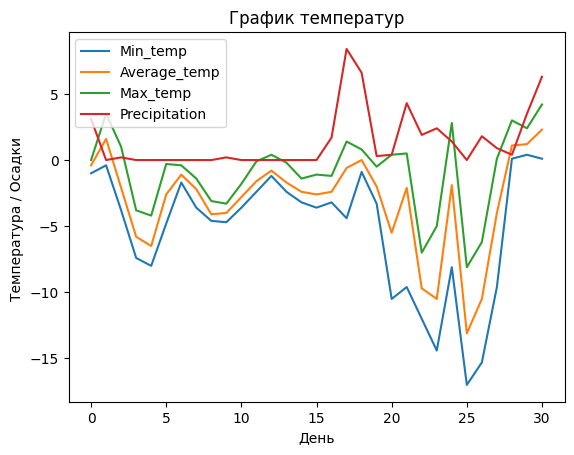

In [ ]:
plt.plot(month_df, label=month_df.columns)
plt.ylabel('Температура / Осадки ')
plt.xlabel('День')
plt.title('График температур')
plt.legend(loc='upper left')
plt.show();

#Выявление пропусков

##Посмотрим информацию о нашем датафрейме. Всего в нем может быть 8766 записей. При этом в последних четырех столбцах записей меньше, а значит есть пропуски

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Station_id     8766 non-null   int64  
 1   Year           8766 non-null   int64  
 2   Month          8766 non-null   int64  
 3   Day            8766 non-null   int64  
 4   Min_temp       8734 non-null   float64
 5   Average_temp   8734 non-null   float64
 6   Max_temp       8734 non-null   float64
 7   Precipitation  8706 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 548.0 KB


##При момощи функций isna() и sum() посчитаем количество пропусков по всем столбцам

In [ ]:
df.isna().sum()

,0
Station_id,0
Year,0
Month,0
Day,0
Min_temp,32
Average_temp,32
Max_temp,32
Precipitation,60


In [ ]:
df[df.isna().any(axis=1)]

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
2405,34730,2006,8,2,NaN,NaN,NaN,NaN
4749,34730,2013,1,1,NaN,NaN,NaN,NaN
4750,34730,2013,1,2,NaN,NaN,NaN,NaN
4751,34730,2013,1,3,NaN,NaN,NaN,NaN
4752,34730,2013,1,4,NaN,NaN,NaN,NaN
4753,34730,2013,1,5,NaN,NaN,NaN,NaN
4754,34730,2013,1,6,NaN,NaN,NaN,NaN
4755,34730,2013,1,7,NaN,NaN,NaN,NaN
4756,34730,2013,1,8,NaN,NaN,NaN,NaN
4757,34730,2013,1,9,NaN,NaN,NaN,NaN


##Найдем процент пропущенных значений. Обращаем внимание, что эти значения относительно не большие.

In [ ]:
(df.isna().sum() / len(df)) * 100

,0
Station_id,0.000000
Year,0.000000
Month,0.000000
Day,0.000000
Min_temp,0.365047
Average_temp,0.365047
Max_temp,0.365047
Precipitation,0.684463


#Заполнение пропусков. Заполним пропуски несколькими способами.

###Способ 1 - заполнение средними арифметическими (fillna() + mean())

In [ ]:
df_mean = df[df.isna().any(axis=1)]

In [ ]:
df_mean

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
2405,34730,2006,8,2,NaN,NaN,NaN,NaN
4749,34730,2013,1,1,NaN,NaN,NaN,NaN
4750,34730,2013,1,2,NaN,NaN,NaN,NaN
4751,34730,2013,1,3,NaN,NaN,NaN,NaN
4752,34730,2013,1,4,NaN,NaN,NaN,NaN
4753,34730,2013,1,5,NaN,NaN,NaN,NaN
4754,34730,2013,1,6,NaN,NaN,NaN,NaN
4755,34730,2013,1,7,NaN,NaN,NaN,NaN
4756,34730,2013,1,8,NaN,NaN,NaN,NaN
4757,34730,2013,1,9,NaN,NaN,NaN,NaN


In [ ]:
df_mean = df_mean.fillna(df.mean())

In [ ]:
df_mean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 2405 to 7822
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Station_id     60 non-null     int64  
 1   Year           60 non-null     int64  
 2   Month          60 non-null     int64  
 3   Day            60 non-null     int64  
 4   Min_temp       60 non-null     float64
 5   Average_temp   60 non-null     float64
 6   Max_temp       60 non-null     float64
 7   Precipitation  60 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 4.2 KB


In [ ]:
df_mean[df.isna().any(axis=1)]

<ipython-input-53-fe9197673394>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mean[df.isna().any(axis=1)]


,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
2405,34730,2006,8,2,6.763407,10.900149,15.809652,1.694142
4749,34730,2013,1,1,6.763407,10.900149,15.809652,1.694142
4750,34730,2013,1,2,6.763407,10.900149,15.809652,1.694142
4751,34730,2013,1,3,6.763407,10.900149,15.809652,1.694142
4752,34730,2013,1,4,6.763407,10.900149,15.809652,1.694142
4753,34730,2013,1,5,6.763407,10.900149,15.809652,1.694142
4754,34730,2013,1,6,6.763407,10.900149,15.809652,1.694142
4755,34730,2013,1,7,6.763407,10.900149,15.809652,1.694142
4756,34730,2013,1,8,6.763407,10.900149,15.809652,1.694142
4757,34730,2013,1,9,6.763407,10.900149,15.809652,1.694142


###Способ 2 - заполнение медианой (fillna() + median())

In [ ]:
df_median = df[df.isna().any(axis=1)]

In [ ]:
df_median = df_median.fillna(df.median())

In [ ]:
df_median[df.isna().any(axis=1)]

<ipython-input-44-8042965b3dc2>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_median[df.isna().any(axis=1)]


,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
2405,34730,2006,8,2,6.9,11.2,16.5,0.0
4749,34730,2013,1,1,6.9,11.2,16.5,0.0
4750,34730,2013,1,2,6.9,11.2,16.5,0.0
4751,34730,2013,1,3,6.9,11.2,16.5,0.0
4752,34730,2013,1,4,6.9,11.2,16.5,0.0
4753,34730,2013,1,5,6.9,11.2,16.5,0.0
4754,34730,2013,1,6,6.9,11.2,16.5,0.0
4755,34730,2013,1,7,6.9,11.2,16.5,0.0
4756,34730,2013,1,8,6.9,11.2,16.5,0.0
4757,34730,2013,1,9,6.9,11.2,16.5,0.0


###Способ 3 - использовать метод interpolate()

In [ ]:
df_inter = df.interpolate(method='linear', limit_direction='forward', axis=0)

In [ ]:
df_inter[df.isna().any(axis=1)]

,Station_id,Year,Month,Day,Min_temp,Average_temp,Max_temp,Precipitation
2405,34730,2006,8,2,16.600000,23.300,30.750000,0.000000
4749,34730,2013,1,1,-3.846875,-0.975,1.909375,0.134375
4750,34730,2013,1,2,-3.793750,-0.950,1.918750,0.268750
4751,34730,2013,1,3,-3.740625,-0.925,1.928125,0.403125
4752,34730,2013,1,4,-3.687500,-0.900,1.937500,0.537500
4753,34730,2013,1,5,-3.634375,-0.875,1.946875,0.671875
4754,34730,2013,1,6,-3.581250,-0.850,1.956250,0.806250
4755,34730,2013,1,7,-3.528125,-0.825,1.965625,0.940625
4756,34730,2013,1,8,-3.475000,-0.800,1.975000,1.075000
4757,34730,2013,1,9,-3.421875,-0.775,1.984375,1.209375


In [ ]:
df_inter_hist = df_inter[df.isna().any(axis=1)]

In [ ]:
df_inter_hist.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 2405 to 7822
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Station_id     60 non-null     int64  
 1   Year           60 non-null     int64  
 2   Month          60 non-null     int64  
 3   Day            60 non-null     int64  
 4   Min_temp       60 non-null     float64
 5   Average_temp   60 non-null     float64
 6   Max_temp       60 non-null     float64
 7   Precipitation  60 non-null     float64
dtypes: float64(4), int64(4)
memory usage: 4.2 KB


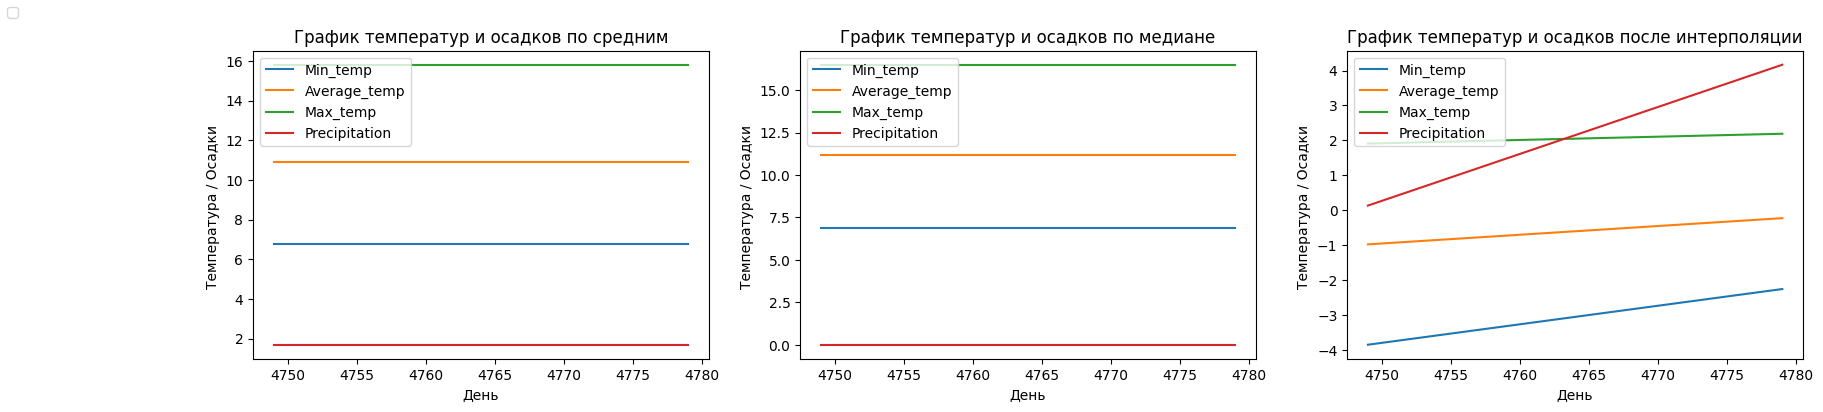

In [ ]:
fig = plt.figure(figsize=(20, 4))
plt.subplot(1, 3, 1)
y_mean = df_mean[(df_mean['Year'] == 2013) & (df_mean['Month'] == 1)].drop(["Station_id", "Year", "Month", "Day"], axis=1)
plt.plot(y_mean, label=month_df.columns)
plt.ylabel('Температура / Осадки ')
plt.xlabel('День')
plt.title('График температур и осадков по средним')
plt.legend(loc='upper left')

plt.subplot(1, 3, 2)
y_median = df_median[(df_median['Year'] == 2013) & (df_mean['Month'] == 1)].drop(["Station_id", "Year", "Month", "Day"], axis=1)
plt.plot(y_median, label=month_df.columns)
plt.ylabel('Температура / Осадки ')
plt.xlabel('День')
plt.title('График температур и осадков по медиане')
plt.legend(loc='upper left')

plt.subplot(1, 3, 3)
y_inter_hist = df_inter_hist[(df_inter_hist['Year'] == 2013) & (df_mean['Month'] == 1)].drop(["Station_id", "Year", "Month", "Day"], axis=1)
plt.plot(y_inter_hist, label=month_df.columns)
plt.ylabel('Температура / Осадки ')
plt.xlabel('День')
plt.title('График температур и осадков после интерполяции')
plt.legend(loc='upper left')
plt.show();

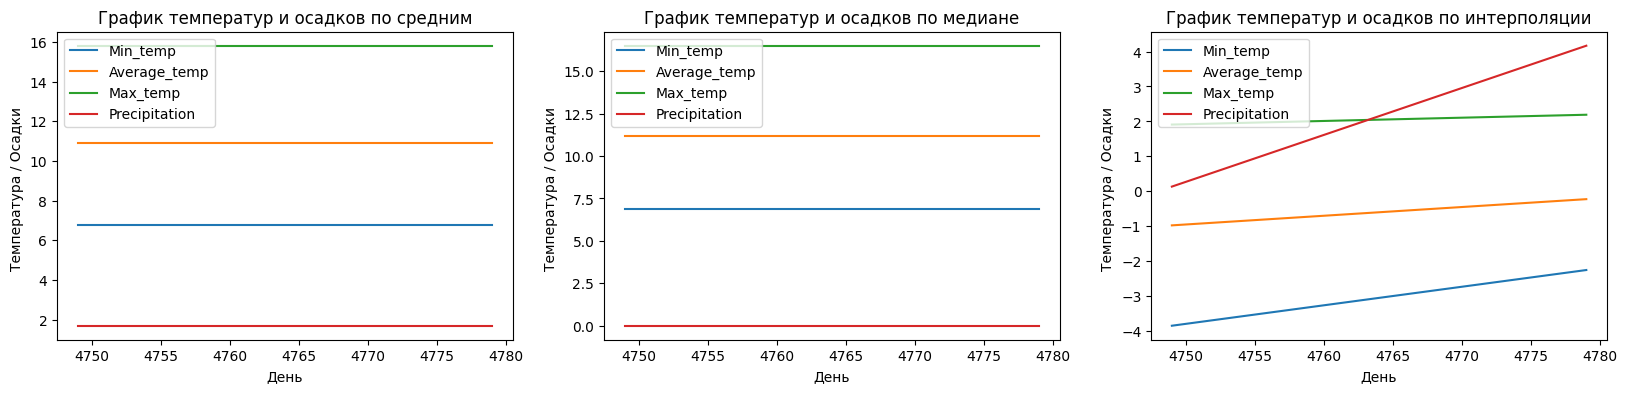

In [ ]:
lst = [y_mean, y_median, y_inter_hist]
lst_text = ['средним', 'медиане', 'интерполяции']
fig = plt.figure(figsize=(20, 4))
for i in range(1,4):
  plt.subplot(1, 3, i)
  plt.plot(lst[i-1], label=month_df.columns)
  plt.ylabel('Температура / Осадки ')
  plt.xlabel('День')
  plt.title(f'График температур и осадков по {lst_text[i-1]}')
  plt.legend(loc='upper left')
plt.show();

#Удаление пропусков

<Axes: xlabel='Min_temp', ylabel='Count'>

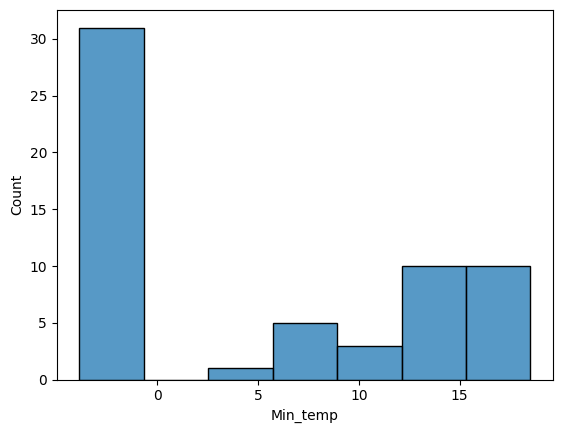

In [ ]:
# sns.histplot(data=df_inter_hist, x='Min_temp')

In [ ]:
import seaborn as sns

In [ ]:
# sns.histplot(data=df, x='Min_temp')

In [ ]:
# df['Min_temp'].ffill(inplace=True)

In [ ]:
# df[['Average_temp', 'Max_temp', 'Precipitation']].ffill(inplace=True)

In [ ]:
# df[df.isna().any(axis=1)]

In [ ]:
# df_mean_Yan = df[~(df["Year"] == 2000) | ~(df["Month"] == 1)]

In [ ]:
# pd.set_option('display.max_rows', None)
# df_mean_Yan